Nama : Nadir Abika

NIM : 240401010132

Kelas : IF403

In [14]:
#1 Load & inspect dataset
import pandas as pd
import numpy as py
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset('tips')
print(df.shape, df.dtypes)
print(df.describe().round(2))

(244, 7) total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object
       total_bill     tip    size
count      244.00  244.00  244.00
mean        19.79    3.00    2.57
std          8.90    1.38    0.95
min          3.07    1.00    1.00
25%         13.35    2.00    2.00
50%         17.80    2.90    2.00
75%         24.13    3.56    3.00
max         50.81   10.00    6.00


/tmp/ipykernel_640/3782847697.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_by_day = df.groupby('day')['total_bill'].mean()


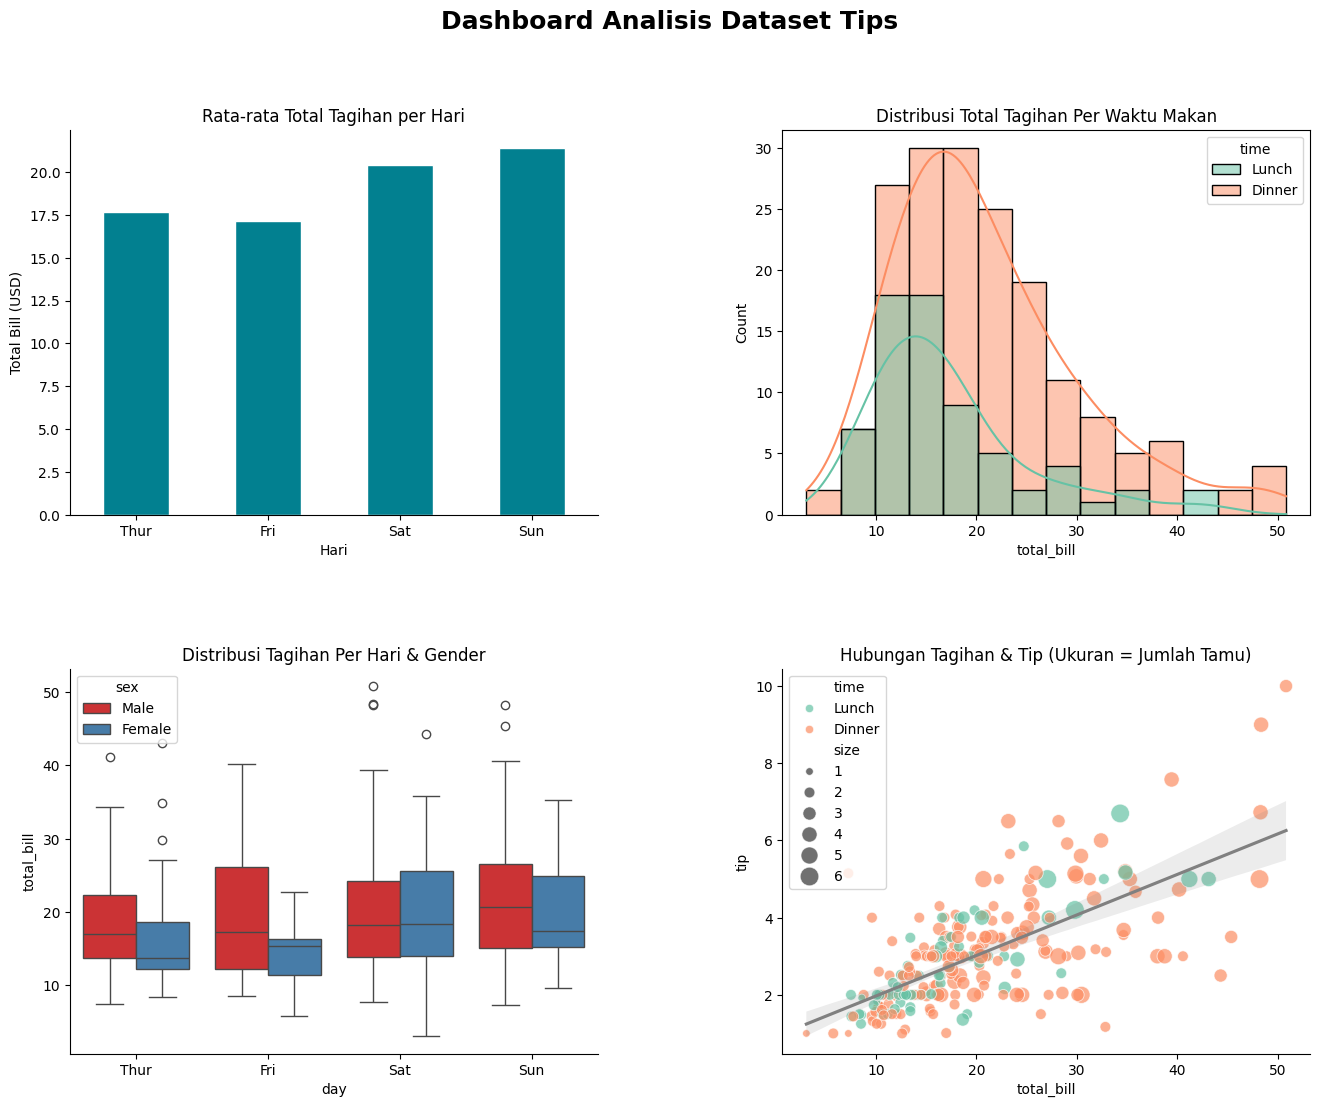

Dashboard tersimpan sebagai dashboard tips.png


In [15]:
#2 Setup figure layout
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Dashboard Analisis Dataset Tips',
             fontsize=18, fontweight='bold')
# Grid 2 x 2 subplot
gs = fig.add_gridspec(2, 2, figure=fig,
                      hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

#3 Grafik 1: Bar chart
avg_by_day = df.groupby('day')['total_bill'].mean()
avg_by_day.plot(
    kind='bar',
    ax=ax1,
    color='#028090',
    edgecolor='white',
    width=0.5)
ax1.set_title('Rata-rata Total Tagihan per Hari')
ax1.set_xlabel('Hari'); ax1.set_ylabel('Total Bill (USD)')
ax1.tick_params(axis='x', rotation=0)
ax1.spines[['top', 'right']].set_visible(False)

#4 Grafik 2: Histogram + KDE
sns.histplot(data=df, x='total_bill', hue='time',
             kde=True, palette='Set2', ax=ax2)
ax2.set_title('Distribusi Total Tagihan Per Waktu Makan')
ax2.spines[['top','right']].set_visible=(False)

#5 Grafik 3: Boxplot
sns.boxplot(data=df, x='day', y='total_bill',
            hue='sex', palette='Set1', ax=ax3)
ax3.set_title('Distribusi Tagihan Per Hari & Gender')
ax3.spines[['top', 'right']].set_visible(False)

#6 Grafik 4: Scatterplot
sns.scatterplot(data=df, x='total_bill', y='tip',
                hue='time', size='size', sizes=(30, 180),
                palette='Set2', alpha=0.7, ax=ax4)
sns.regplot(data=df, x='total_bill', y='tip',
            scatter=False, color='gray', ax=ax4)
ax4.set_title('Hubungan Tagihan & Tip (Ukuran = Jumlah Tamu)')
ax4.spines[['top', 'right']].set_visible(False)

#7 Ekspor
plt.savefig('dashboard_tips.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard tersimpan sebagai dashboard tips.png')


# **ANALISIS CHARTS**

**1. BAR CHART**


**What?**

Grafik menunjukkan total tagihan rata-rata pelanggan dari hari Kamis sampai Minggu. Rata-rata tagihan terendah terjadi pada hari Minggu dengan nilai sekitar 21,4 USD, diikuti oleh hari Sabtu sekitar 20,3 USD. Hari Kamis dan Jumat menunjukkan rata-rata yang lebih kecil, masing-masing sekitar 17,7 USD dan 17,2 USD.

**So what?**

Data ini mengindikasikan bahwa konsumen cenderung membelanjakan lebih banyak uang di akhir pekan dibandingkan dengan hari kerja. Kenaikan dari Jumat ke Minggu menyentuh sekitar 4,2 USD per transaksi rata-rata, yang menunjukkan lonjakan aktivitas bersantap di luar pada akhir pekan. Data ini krusial untuk pengaturan persediaan, manajemen tenaga kerja, dan taktik pemasaran restoran.

**Now what?**


Manajemen dapat menambah persediaan dan jumlah karyawan pada hari Sabtu dan Minggu guna menghadapi peningkatan pengeluaran pelanggan. Perlu diselidiki lebih lanjut apakah peningkatan ini disebabkan oleh bertambahnya jumlah pelanggan atau akibat pelanggan memilih menu yang lebih mahal. Analisis lebih lanjut mengenai jenis menu yang paling banyak dipesan pada akhir pekan juga bisa dilakukan.

**2. hostogram**

**What?**

Histogram menggambarkan sebaran total biaya untuk pelanggan Makan Siang dan Makan Malam. Sebagian besar transaksi untuk makan siang berkisar antara 10–20 USD, sementara transaksi untuk makan malam lebih banyak tersebar dalam rentang 15–30 USD. Jumlah tagihan tertinggi juga terjadi saat waktu makan malam dengan transaksi mencapai sekitar 50 USD.

**So what?**

Pola ini menunjukkan bahwa pelanggan pada saat makan malam cenderung menghabiskan uang lebih banyak dibandingkan saat makan siang. Distribusi yang lebih luas dalam kategori Dinner menunjukkan variasi biaya yang lebih signifikan dan peluang pendapatan yang lebih besar. Penemuan ini krusial untuk menetapkan arah promosi dan pengelolaan operasional berdasar waktu layanan.

**Now what?**

Restoran bisa menekankan promosi menu premium atau paket keluarga saat waktu makan malam karena kekuatan membeli pelanggan lebih besar. Analisis yang lebih mendalam dapat menilai apakah perbedaan ini dipengaruhi oleh jumlah anggota kelompok pelanggan atau jenis makanan yang dipesan. Di samping itu, perlu dianalisis apakah margin keuntungan juga lebih tinggi selama periode makan malam.

**3. BOXPLOT**

**What?**

Boxplot menunjukkan distribusi total tagihan berdasarkan hari dan jenis kelamin konsumen. Pada hari Minggu, pria sebagai pelanggan memiliki median tagihan sekitar 21 USD, sedikit lebih tinggi dibandingkan dengan wanita pelanggan yang sekitar 18 USD. Beberapa transaksi ekstrem (outlier) terlihat pada hari Sabtu dan Minggu dengan jumlah tagihan mencapai 45–51 USD.

**So what?**

Perbedaan median menunjukkan variasi pola pengeluaran antara pelanggan pria dan wanita, meskipun tidak signifikan. Banyaknya outlier yang muncul di akhir pekan menunjukkan terdapat kelompok pelanggan yang melakukan transaksi dengan nilai tinggi. Data ini krusial untuk mengenali segmen pelanggan yang memberikan kontribusi signifikan terhadap pendapatan.

**Now what?**

Diperlukan analisis segmentasi pelanggan yang lebih mendalam untuk memahami karakteristik transaksi dengan nilai tinggi tersebut. Restoran dapat memikirkan program loyalitas atau penawaran eksklusif untuk segmen pelanggan dengan pengeluaran tinggi. Analisis lebih lanjut tentang keterkaitan gender, ukuran kelompok, dan jenis menu yang dipilih bisa memberikan pemahaman yang lebih mendalam.

**4. SCATTER PLOT**

**What?**

Hasil dari scatter plot menunjukkan adanya hubungan positif antara total biaya dan jumlah tip yang diberikan oleh pelanggan. Saat total tagihan naik dari sekitar 10 USD menjadi 50 USD, nilai tip juga cenderung naik dari sekitar 1–2 USD menjadi 6–10 USD. Titik maksimum (ukuran kelompok hingga 6 orang) umumnya terletak di area tagihan dan tip yang lebih tinggi.

**So what?**

Hubungan yang baik ini mengindikasikan bahwa semakin tinggi nilai transaksi, semakin banyak pula tip yang diperoleh. Hal ini krusial karena tip dapat menunjukkan kepuasan pelanggan dan juga menjadi sumber pendapatan ekstra bagi staf layanan. Di samping itu, ukuran grup yang lebih besar sepertinya berperan dalam meningkatkan total tagihan dan tips.

**Now what?**

Restoran dapat meningkatkan pendapatan dan tips dengan menawarkan paket kelompok atau menu bundling yang mendorong transaksi bernilai tinggi. Analisis yang lebih mendalam dapat menghitung koefisien korelasi untuk menilai seberapa kuat keterkaitan antara tagihan dan tip. Studi lebih lanjut juga dapat menyelidiki apakah jam makan (Makan Siang atau Makan Malam) berpengaruh pada persentase tip yang diberikan oleh pelanggan.